This notebook is used to extend the base model by introducing SVI

In [ ]:
# load libraries
library(tidyverse)
library(janitor)
library(MASS)         # glm.nb
library(broom)
library(broom.mixed)

In [3]:
county_data <- read_csv("data/county_data.csv")
svi_data <- read_csv("data/svi_interactive_map.csv")

# names(county_data)
# names(svi_data)

clean_county <- function(x) {
  x %>%
    str_to_upper() %>%
    str_replace_all("\\s+COUNTY$", "") %>%
    str_replace_all("\\.", "") %>%
    str_squish()
}

county_data <- county_data %>%
  mutate(county_key = clean_county(County))

svi_data <- svi_data %>%
  mutate(county_key = clean_county(COUNTY))

svi_keep <- svi_data %>%
  dplyr::select(
    county_key,
    COUNTY,
    FIPS,
    E_TOTPOP,
    RPL_THEMES,
    RPL_THEME1, RPL_THEME2, RPL_THEME3, RPL_THEME4,
    EPL_POV150, EPL_UNEMP, EPL_HBURD, EPL_NOHSDP, EPL_UNINSUR,
    EPL_AGE65, EPL_AGE17, EPL_DISABL, EPL_SNGPNT, EPL_LIMENG,
    EPL_MINRTY,
    EPL_MUNIT, EPL_MOBILE, EPL_CROWD, EPL_NOVEH, EPL_GROUPQ,
    EP_POV150, EP_UNEMP, EP_HBURD, EP_NOHSDP, EP_UNINSUR,
    EP_AGE65, EP_AGE17, EP_DISABL, EP_SNGPNT, EP_LIMENG,
    EP_MINRTY,
    EP_MUNIT, EP_MOBILE, EP_CROWD, EP_NOVEH, EP_GROUPQ
  ) %>%
  mutate(across(where(is.numeric), ~na_if(., -999)))

Rows: 254 Columns: 5
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (1): County
dbl (4): cve, outbreak, enrollment, PHR

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 254 Columns: 160
-- Column specification --------------------------------------------------------
Delimiter: ","
chr   (6): STATE, ST_ABBR, COUNTY, LOCATION, GeoLevel, Comparison
dbl (154): ST, STCNTY, FIPS, AREA_SQMI, E_TOTPOP, M_TOTPOP, E_HU, M_HU, E_HH...

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
county_full <- county_data %>%
  left_join(svi_keep, by = "county_key")

class(county_full$population)
str(county_full$population)
glimpse(county_full)

county_full <- county_full %>%
  mutate(population = E_TOTPOP)

summary_stats <- county_full %>%
  summarise(
    outbreak_mean = mean(outbreak, na.rm = TRUE),
    outbreak_sd   = sd(outbreak, na.rm = TRUE),
    outbreak_min  = min(outbreak, na.rm = TRUE),
    outbreak_max  = max(outbreak, na.rm = TRUE),

    cve_mean = mean(cve, na.rm = TRUE),
    cve_sd   = sd(cve, na.rm = TRUE),
    cve_min  = min(cve, na.rm = TRUE),
    cve_max  = max(cve, na.rm = TRUE),

    population_mean = mean(population, na.rm = TRUE),
    population_sd   = sd(population, na.rm = TRUE),
    population_min  = min(population, na.rm = TRUE),
    population_max  = max(population, na.rm = TRUE),

    enrollment_mean = mean(enrollment, na.rm = TRUE),
    enrollment_sd   = sd(enrollment, na.rm = TRUE),
    enrollment_min  = min(enrollment, na.rm = TRUE),
    enrollment_max  = max(enrollment, na.rm = TRUE),

    svi_overall_mean = mean(RPL_THEMES, na.rm = TRUE),
    svi_overall_sd   = sd(RPL_THEMES, na.rm = TRUE),
    svi_overall_min  = min(RPL_THEMES, na.rm = TRUE),
    svi_overall_max  = max(RPL_THEMES, na.rm = TRUE),

    theme1_mean = mean(RPL_THEME1, na.rm = TRUE),
    theme2_mean = mean(RPL_THEME2, na.rm = TRUE),
    theme3_mean = mean(RPL_THEME3, na.rm = TRUE),
    theme4_mean = mean(RPL_THEME4, na.rm = TRUE)
  )

print(summary_stats)

Warning message:
"Unknown or uninitialised column: `population`."


[1] "NULL"

Warning message:
"Unknown or uninitialised column: `population`."


 NULL
Rows: 254
Columns: 46
$ County      <chr> "Anderson", "Andrews", "Angelina", "Aransas", "Archer", "A~
$ cve         <dbl> 2.54, 1.91, 2.50, 2.06, 2.70, 5.24, 1.08, 3.55, 0.80, 3.78~
$ outbreak    <dbl> 0, 3, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0~
$ enrollment  <dbl> 7808, 4209, 15649, 2913, 2110, 297, 9046, 6290, 1330, 2461~
$ PHR         <dbl> 4, 9, 5, 11, 2, 1, 8, 6, 1, 8, 7, 2, 11, 7, 8, 7, 1, 7, 4,~
$ county_key  <chr> "ANDERSON", "ANDREWS", "ANGELINA", "ARANSAS", "ARCHER", "A~
$ COUNTY      <chr> "Anderson County", "Andrews County", "Angelina County", "A~
$ FIPS        <dbl> 48001, 48003, 48005, 48007, 48009, 48011, 48013, 48015, 48~
$ E_TOTPOP    <dbl> 58077, 18362, 86608, 24048, 8649, 1912, 49403, 30406, 6902~
$ RPL_THEMES  <dbl> 0.7075, 0.6087, 0.9289, 0.4783, 0.0395, 0.0079, 0.8063, 0.~
$ RPL_THEME1  <dbl> 0.5850, 0.7036, 0.8498, 0.5020, 0.1502, 0.0158, 0.7312, 0.~
$ RPL_THEME2  <dbl> 0.1897, 0.4625, 0.9249, 0.1304, 0.2688, 0.1186, 0.7312, 0.~
$ RPL_THEME3

In [5]:
# Add NCHS urban-rural classification
library(readr)
library(stringr)
library(dplyr)

urban_df <- read_csv("out/urban_rural_classification.csv") %>%
  clean_names()

# Inspect file
glimpse(urban_df)
table(urban_df$state)
table(urban_df$x2023_code)

# Keep Texas counties only
urban_tx <- urban_df %>%
  filter(state == "TX") %>%
  mutate(
    FIPS = as.numeric(location),
    urban_code = as.numeric(str_extract(x2023_code, "^[0-9]+")),
    urban_class = str_remove(x2023_code, "^[0-9]+ - "),
    urban_class = factor(
      urban_class,
      levels = c(
        "Large central metro",
        "Large fringe metro",
        "Medium metro",
        "Small metro",
        "Micropolitan",
        "Noncore"
      )
    )
  ) %>%
  dplyr::select(FIPS, urban_code, urban_class)

# Merge into county_full
county_full <- county_full %>%
  mutate(
    FIPS = as.numeric(FIPS),
    population = E_TOTPOP
  ) %>%
  left_join(urban_tx, by = "FIPS")

# Check merge
county_full %>%
  summarise(
    n_counties = n(),
    matched_urban = sum(!is.na(urban_class)),
    missing_urban = sum(is.na(urban_class))
  )

county_full %>%
  count(urban_class, sort = TRUE)


Rows: 3144 Columns: 5
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (5): FullGeoName, Location, State, County_name, 2023 Code

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message in FUN(X[[i]], ...):
"kann '<U+00C4>' nicht in native Kodierung "ubersetzen"
Warning message in FUN(X[[i]], ...):
"kann '<U+00D6>' nicht in native Kodierung "ubersetzen"
Warning message in FUN(X[[i]], ...):
"kann '<U+00DC>' nicht in native Kodierung "ubersetzen"
Warning message in FUN(X[[i]], ...):
"kann '<U+00E4>' nicht in native Kodierung "ubersetzen"
Warning message in FUN(X[[i]], ...):
"kann '<U+00F6>' nicht in native Kodierung "ubersetzen"
Warning message in FUN(X[[i]], ...):
"kann '<U+00FC>' nicht in native Kodierung "ubersetzen"
Warning message in FUN(X[[i]], ...):
"kann '<U+00DF>' nicht in native Kodierung "ubersetzen"
Warning messag

Rows: 3,144
Columns: 5
$ full_geo_name <chr> "AK, Aleutians East Borough", "AK, Aleutians West Ca", "~
$ location      <chr> "02013", "02016", "02020", "02050", "02060", "02063", "0~
$ state         <chr> "AK", "AK", "AK", "AK", "AK", "AK", "AK", "AK", "AK", "A~
$ county_name   <chr> "Aleutians East Borough", "Aleutians West Census Area", ~
$ x2023_code    <chr> "6 - Noncore", "6 - Noncore", "3 - Medium metro", "6 - N~



 AK  AL  AR  AZ  CA  CO  CT  DC  DE  FL  GA  HI  IA  ID  IL  IN  KS  KY  LA  MA 
 30  67  75  15  58  64   9   1   3  67 159   5  99  44 102  92 105 120  64  14 
 MD  ME  MI  MN  MO  MS  MT  NC  ND  NE  NH  NJ  NM  NV  NY  OH  OK  OR  PA  RI 
 24  16  83  87 115  82  56 100  53  93  10  21  33  17  62  88  77  36  67   5 
 SC  SD  TN  TX  UT  VA  VT  WA  WI  WV  WY 
 46  66  95 254  29 133  14  39  72  55  23 


1 - Large central metro  2 - Large fringe metro        3 - Medium metro 
                     67                     368                     395 
        4 - Small metro        5 - Micropolitan             6 - Noncore 
                    356                     658                    1300 

n_counties,matched_urban,missing_urban
<int>,<int>,<int>
254,254,0


urban_class,n
<fct>,<int>
Noncore,121
Micropolitan,47
Medium metro,35
Large fringe metro,28
Small metro,17
Large central metro,6


In [6]:
library(dplyr)
library(tibble)
library(MASS)

county_full <- county_full %>%
  mutate(across(where(is.numeric), ~ na_if(., -999))) %>%
  mutate(population = E_TOTPOP)

# variables to test one at a time
svi_vars <- c(
  "EP_POV150", "EP_UNEMP", "EP_HBURD", "EP_NOHSDP", "EP_UNINSUR",
  "EP_AGE65", "EP_AGE17", "EP_DISABL", "EP_SNGPNT", "EP_LIMENG",
  "EP_MINRTY",
  "EP_MUNIT", "EP_MOBILE", "EP_CROWD", "EP_NOVEH", "EP_GROUPQ"
)

run_nb_safe <- function(v, data = county_full) {
  
  df <- data %>%
    dplyr::select(outbreak, population, all_of(v)) %>%
    filter(
      !is.na(outbreak),
      !is.na(population),
      is.finite(population),
      population > 0,
      !is.na(.data[[v]]),
      is.finite(.data[[v]])
    )
  
  # too few rows
  if (nrow(df) < 20) {
    return(tibble(
      variable = v,
      estimate = NA_real_,
      std_error = NA_real_,
      z_value = NA_real_,
      p_value = NA_real_,
      irr = NA_real_,
      conf_low = NA_real_,
      conf_high = NA_real_,
      aic = NA_real_,
      n = nrow(df),
      note = "too few usable rows"
    ))
  }
  
  # no variation
  s <- sd(df[[v]], na.rm = TRUE)
  if (is.na(s) || s == 0) {
    return(tibble(
      variable = v,
      estimate = NA_real_,
      std_error = NA_real_,
      z_value = NA_real_,
      p_value = NA_real_,
      irr = NA_real_,
      conf_low = NA_real_,
      conf_high = NA_real_,
      aic = NA_real_,
      n = nrow(df),
      note = "no variation"
    ))
  }
  
  # safe manual standardization
  df <- df %>%
    mutate(x = (.data[[v]] - mean(.data[[v]], na.rm = TRUE)) / sd(.data[[v]], na.rm = TRUE))
  
  tryCatch({
    m <- glm.nb(
      outbreak ~ x + offset(log(population)),
      data = df,
      control = glm.control(maxit = 100)
    )
    
    sm <- coef(summary(m))
    ci <- suppressMessages(confint.default(m))
    
    tibble(
      variable = v,
      estimate = unname(sm["x", "Estimate"]),
      std_error = unname(sm["x", "Std. Error"]),
      z_value = unname(sm["x", "z value"]),
      p_value = unname(sm["x", "Pr(>|z|)"]),
      irr = unname(exp(coef(m)["x"])),
      conf_low = unname(exp(ci["x", 1])),
      conf_high = unname(exp(ci["x", 2])),
      aic = AIC(m),
      n = nrow(df),
      note = "ok"
    )
  }, error = function(e) {
    tibble(
      variable = v,
      estimate = NA_real_,
      std_error = NA_real_,
      z_value = NA_real_,
      p_value = NA_real_,
      irr = NA_real_,
      conf_low = NA_real_,
      conf_high = NA_real_,
      aic = NA_real_,
      n = nrow(df),
      note = as.character(e$message)
    )
  })
}

# all results
nb_results <- bind_rows(lapply(svi_vars, run_nb_safe)) %>%
  arrange(p_value)

print(nb_results)

# successful fits only, formatted nicely
nb_results_ok <- nb_results %>%
  filter(note == "ok") %>%
  mutate(
    stars = case_when(
      is.na(p_value) ~ "",
      p_value < 0.001 ~ "***",
      p_value < 0.01  ~ "**",
      p_value < 0.05  ~ "*",
      p_value < 0.1   ~ ".",
      TRUE ~ ""
    ),
    estimate  = round(estimate, 4),
    std_error = round(std_error, 4),
    z_value   = round(z_value, 3),
    p_value   = round(p_value, 4),
    irr       = round(irr, 3),
    conf_low  = round(conf_low, 3),
    conf_high = round(conf_high, 3),
    aic       = round(aic, 2),
    p_display = paste0(format(p_value, nsmall = 4), stars)
  ) %>%
  dplyr::select(
    variable, estimate, std_error, z_value, p_value, stars,
    p_display, irr, conf_low, conf_high, aic, n
  ) %>%
  arrange(p_value)

print(nb_results_ok)

Warning message:
"Schrittweite abgeschnitten wegen Divergenz"
Warning message:
"Schrittweite abgeschnitten wegen Divergenz"
Warning message:
"Schrittweite abgeschnitten wegen Divergenz"
Warning message:
"glm.fit: Algorithmus konvergierte nicht"


# A tibble: 16 x 11
   variable  estimate std_error z_value  p_value    irr conf_low conf_high   aic
   <chr>        <dbl>     <dbl>   <dbl>    <dbl>  <dbl>    <dbl>     <dbl> <dbl>
 1 EP_LIMENG   1.69       0.323   5.23   1.70e-7  5.43    2.88      10.2    438.
 2 EP_AGE65   -2.08       0.457  -4.56   5.01e-6  0.124   0.0508     0.304  428.
 3 EP_MUNIT   -1.18       0.332  -3.54   3.99e-4  0.309   0.161      0.592  441.
 4 EP_DISABL  -1.01       0.383  -2.64   8.26e-3  0.363   0.172      0.770  442.
 5 EP_CROWD    0.873      0.346   2.52   1.17e-2  2.39    1.21       4.72   443.
 6 EP_MINRTY   0.809      0.347   2.33   1.99e-2  2.25    1.14       4.43   445.
 7 EP_HBURD   -0.611      0.343  -1.78   7.46e-2  0.543   0.277      1.06   444.
 8 EP_MOBILE   0.351      0.346   1.01   3.11e-1  1.42    0.721      2.80   446.
 9 EP_SNGPNT   0.284      0.356   0.798  4.25e-1  1.33    0.661      2.67   446.
10 EP_GROUPQ  -0.216      0.350  -0.618  5.36e-1  0.805   0.405      1.60   446.
11 EP_PO

In [7]:
county_full %>%
  group_by(urban_class) %>%
  summarise(
    n = n(),
    mean_outbreak = mean(outbreak, na.rm = TRUE),
    mean_cve = mean(cve, na.rm = TRUE),
    mean_svi = mean(RPL_THEMES, na.rm = TRUE),
    mean_munit = mean(EP_MUNIT, na.rm = TRUE),
    mean_crowd = mean(EP_CROWD, na.rm = TRUE),
    .groups = "drop"
  )

# EP_MUNIT alone
model_munit_1 <- glm.nb(
  outbreak ~ scale(EP_MUNIT) + offset(log(population)),
  data = county_full
)

summary(model_munit_1)

# EP_MUNIT controlling for urban-rural class
model_munit_urban <- glm.nb(
  outbreak ~ scale(EP_MUNIT) + urban_class + offset(log(population)),
  data = county_full
)

summary(model_munit_urban)

# Add CVE and SVI too
model_munit_full <- glm.nb(
  outbreak ~ scale(cve) + scale(RPL_THEMES) + scale(EP_MUNIT) +
    urban_class + offset(log(population)),
  data = county_full
)

summary(model_munit_full)

urban_class,n,mean_outbreak,mean_cve,mean_svi,mean_munit,mean_crowd
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Large central metro,6,0.33333333,2.690000,0.5441333,23.216667,4.666667
Large fringe metro,28,0.07142857,3.236786,0.3337071,5.978571,4.210714
Medium metro,35,4.37142857,2.670286,0.5679257,5.414286,4.034286
Small metro,17,1.23529412,2.838235,0.4040882,5.352941,3.770588
Micropolitan,47,0.93617021,2.139362,0.6568021,4.223404,4.614894
Noncore,121,4.30578512,3.029339,0.4689835,1.465289,3.617355



Call:
glm.nb(formula = outbreak ~ scale(EP_MUNIT) + offset(log(population)), 
    data = county_full, init.theta = 0.03732440166, link = log)

Coefficients:
                Estimate Std. Error z value Pr(>|z|)    
(Intercept)      -9.0713     0.3303 -27.460  < 2e-16 ***
scale(EP_MUNIT)  -1.1754     0.3320  -3.541 0.000399 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for Negative Binomial(0.0373) family taken to be 1)

    Null deviance: 87.209  on 253  degrees of freedom
Residual deviance: 81.412  on 252  degrees of freedom
AIC: 441.09

Number of Fisher Scoring iterations: 1


              Theta:  0.03732 
          Std. Err.:  0.00706 

 2 x log-likelihood:  -435.08900 


Call:
glm.nb(formula = outbreak ~ scale(EP_MUNIT) + urban_class + offset(log(population)), 
    data = county_full, init.theta = 0.04715901472, link = log)

Coefficients:
                              Estimate Std. Error z value Pr(>|z|)    
(Intercept)                   -12.8060     2.7124  -4.721 2.34e-06 ***
scale(EP_MUNIT)                -0.7442     0.4606  -1.616    0.106    
urban_classLarge fringe metro  -1.1370     2.8118  -0.404    0.686    
urban_classMedium metro         4.0630     2.7282   1.489    0.136    
urban_classSmall metro          2.7406     2.8507   0.961    0.336    
urban_classMicropolitan         2.3456     2.7742   0.846    0.398    
urban_classNoncore              4.2612     2.8931   1.473    0.141    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for Negative Binomial(0.0472) family taken to be 1)

    Null deviance: 105.528  on 253  degrees of freedom
Residual deviance:  83.313  on 247  degrees of freedom
AIC: 43


Call:
glm.nb(formula = outbreak ~ scale(cve) + scale(RPL_THEMES) + 
    scale(EP_MUNIT) + urban_class + offset(log(population)), 
    data = county_full, init.theta = 0.07117609214, link = log)

Coefficients:
                              Estimate Std. Error z value Pr(>|z|)    
(Intercept)                   -14.2306     2.2495  -6.326 2.52e-10 ***
scale(cve)                      0.9332     0.3000   3.110  0.00187 ** 
scale(RPL_THEMES)               0.9116     0.3253   2.802  0.00507 ** 
scale(EP_MUNIT)                -0.2296     0.3920  -0.586  0.55803    
urban_classLarge fringe metro   0.3783     2.3104   0.164  0.86995    
urban_classMedium metro         4.4584     2.2535   1.978  0.04788 *  
urban_classSmall metro          4.2248     2.3463   1.801  0.07177 .  
urban_classMicropolitan         3.4434     2.3096   1.491  0.13598    
urban_classNoncore              4.3335     2.4046   1.802  0.07152 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion 

In [11]:
mechanism_df <- county_full %>%
  mutate(
    population = E_TOTPOP
  ) %>%
  dplyr::select(
    County, outbreak, population, cve,
    EP_LIMENG, EP_CROWD, EP_AGE65, EP_DISABL,
    urban_class
  ) %>%
  filter(
    !is.na(outbreak),
    !is.na(population),
    population > 0,
    is.finite(population),
    !is.na(cve),
    !is.na(EP_LIMENG),
    !is.na(EP_CROWD),
    !is.na(EP_AGE65),
    !is.na(EP_DISABL),
    !is.na(urban_class)
  ) %>%
  mutate(
    z_cve    = as.numeric(scale(cve)),
    z_limeng = as.numeric(scale(EP_LIMENG)),
    z_crowd  = as.numeric(scale(EP_CROWD)),
    z_age65  = as.numeric(scale(EP_AGE65)),
    z_disabl = as.numeric(scale(EP_DISABL)),
    urban_class = droplevels(factor(urban_class))
  ) %>%
  filter(
    is.finite(z_cve),
    is.finite(z_limeng),
    is.finite(z_crowd),
    is.finite(z_age65),
    is.finite(z_disabl)
  )

summary(mechanism_df)

#dropped: Multi-unit housing; Disability (compounded with age 65+); Minority (too comfounded)
model_test <- glm.nb(
  outbreak ~ 
    z_cve + z_limeng + z_crowd + z_age65 +
    offset(log(population)),
  data = mechanism_df,
  control = glm.control(maxit = 100)
)

summary(model_test)

# # with urban class (this fails to converge)
# model_mechanism_urban <- glm.nb(
#   outbreak ~ 
#     z_cve +
#     z_limeng +
#     z_crowd +
#     z_age65 +
#     urban_class +
#     offset(log(population)),
#   data = mechanism_df,
#   control = glm.control(maxit = 100)
# )

# summary(model_mechanism_urban)

# Poisson starting values for negative binomial (still fails to converge)
# form_mechanism <- outbreak ~ 
#   z_cve + z_limeng + z_crowd + z_age65 + urban_class +
#   offset(log(population))

# pois_start <- glm(
#   form_mechanism,
#   data = mechanism_df,
#   family = poisson(link = "log")
# )

# model_mechanism_urban <- glm.nb(
#   form_mechanism,
#   data = mechanism_df,
#   start = coef(pois_start),
#   control = glm.control(maxit = 100)
# )

# summary(model_mechanism_urban)

#======================================================================
# mechanism_df <- mechanism_df %>%
#   mutate(
#     urban_binary = case_when(
#       urban_class %in% c("Large central metro", "Large fringe metro", 
#                          "Medium metro", "Small metro") ~ "Metro",
#       urban_class %in% c("Micropolitan", "Noncore") ~ "Nonmetro",
#       TRUE ~ NA_character_
#     ),
#     urban_binary = factor(urban_binary)
#   ) %>%
#   filter(!is.na(urban_binary))

# model_mechanism_binary <- glm.nb(
#   outbreak ~ 
#     z_cve +
#     z_limeng +
#     z_crowd +
#     z_age65 +
#     urban_binary +
#     offset(log(population)),
#   data = mechanism_df,
#   control = glm.control(maxit = 100)
# )

# summary(model_mechanism_binary)

# Build final clean data
clean_df <- mechanism_df %>%
  mutate(
    urban_binary = case_when(
      urban_class %in% c("Large central metro", "Large fringe metro") ~ "Urban",
      TRUE ~ "Nonurban"
    ),
    urban_binary = factor(urban_binary)
  ) %>%
  filter(
    complete.cases(outbreak, population, z_cve, z_limeng, z_crowd, z_age65, urban_binary),
    population > 0
  )

form_mech <- outbreak ~ z_cve + z_limeng + z_crowd + z_age65 + urban_binary +
  offset(log(population))

pois_mech <- glm(
  form_mech,
  data = clean_df,
  family = poisson(link = "log")
)

summary(pois_mech)

# model_mech <- glm.nb(
#   form_mech,
#   data = clean_df,
#   start = coef(pois_mech),
#   control = glm.control(maxit = 200)
# )

# summary(model_mech)

    County             outbreak         population           cve        
 Length:254         Min.   :  0.000   Min.   :     96   Min.   : 0.000  
 Class :character   1st Qu.:  0.000   1st Qu.:   6306   1st Qu.: 1.492  
 Mode  :character   Median :  0.000   Median :  18383   Median : 2.490  
                    Mean   :  2.925   Mean   : 115131   Mean   : 2.817  
                    3rd Qu.:  0.000   3rd Qu.:  52424   3rd Qu.: 3.765  
                    Max.   :414.000   Max.   :4726177   Max.   :14.540  
   EP_LIMENG         EP_CROWD        EP_AGE65       EP_DISABL    
 Min.   : 0.000   Min.   : 0.00   Min.   : 8.40   Min.   : 5.10  
 1st Qu.: 1.700   1st Qu.: 2.40   1st Qu.:14.03   1st Qu.:12.60  
 Median : 3.150   Median : 3.40   Median :17.30   Median :15.40  
 Mean   : 4.486   Mean   : 3.96   Mean   :18.47   Mean   :15.86  
 3rd Qu.: 5.175   3rd Qu.: 5.00   3rd Qu.:21.88   3rd Qu.:18.80  
 Max.   :36.400   Max.   :20.00   Max.   :41.70   Max.   :34.00  
              urban_class  


Call:
glm.nb(formula = outbreak ~ z_cve + z_limeng + z_crowd + z_age65 + 
    offset(log(population)), data = mechanism_df, control = glm.control(maxit = 100), 
    init.theta = 0.0690017518, link = log)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -11.1059     0.3411 -32.562  < 2e-16 ***
z_cve         1.7929     0.3166   5.662 1.49e-08 ***
z_limeng      1.1057     0.3228   3.425 0.000614 ***
z_crowd      -1.0538     0.4298  -2.452 0.014206 *  
z_age65      -2.0562     0.4392  -4.682 2.85e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for Negative Binomial(0.069) family taken to be 1)

    Null deviance: 143.383  on 253  degrees of freedom
Residual deviance:  82.821  on 249  degrees of freedom
AIC: 409.43

Number of Fisher Scoring iterations: 1


              Theta:  0.0690 
          Std. Err.:  0.0137 

 2 x log-likelihood:  -397.4280 


Call:
glm(formula = form_mech, family = poisson(link = "log"), data = clean_df)

Coefficients:
                   Estimate Std. Error z value Pr(>|z|)    
(Intercept)       -11.10675    0.10221 -108.66   <2e-16 ***
z_cve               1.02617    0.01911   53.69   <2e-16 ***
z_limeng            1.02250    0.04969   20.58   <2e-16 ***
z_crowd            -1.75184    0.10473  -16.73   <2e-16 ***
z_age65            -1.41295    0.10295  -13.72   <2e-16 ***
urban_binaryUrban  -6.16800    0.50420  -12.23   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 7264.9  on 253  degrees of freedom
Residual deviance: 1192.1  on 248  degrees of freedom
AIC: 1324.8

Number of Fisher Scoring iterations: 8


In [12]:
library(dplyr)
library(MASS)

analysis_df <- county_full %>%
  mutate(
    population = E_TOTPOP
  ) %>%
  filter(
    !is.na(outbreak),
    !is.na(population),
    population > 0,
    !is.na(EP_LIMENG),
    !is.na(EP_CROWD),
    !is.na(EP_MINRTY),
    !is.na(EP_AGE65)
  ) %>%
  mutate(
    z_limeng = as.numeric(scale(EP_LIMENG)),
    z_crowd  = as.numeric(scale(EP_CROWD)),
    z_minrty = as.numeric(scale(EP_MINRTY)),
    z_age65  = as.numeric(scale(EP_AGE65))
  ) %>%
  filter(
    is.finite(z_limeng),
    is.finite(z_crowd),
    is.finite(z_minrty),
    is.finite(z_age65)
  )

form_selected <- outbreak ~ 
  z_limeng + z_crowd + z_minrty + z_age65 +
  offset(log(population))

# first fit Poisson to get starting values
pois_selected <- glm(
  form_selected,
  data = analysis_df,
  family = poisson(link = "log")
)

print(pois_selected)

# then fit NB using Poisson coefficients as starts
model_selected <- glm.nb(
  form_selected,
  data = analysis_df,
  start = coef(pois_selected),
  control = glm.control(maxit = 100)
)

summary(model_selected)


Call:  glm(formula = form_selected, family = poisson(link = "log"), 
    data = analysis_df)

Coefficients:
(Intercept)     z_limeng      z_crowd     z_minrty      z_age65  
    -15.201        1.458        1.297       -3.918       -4.868  

Degrees of Freedom: 253 Total (i.e. Null);  249 Residual
Null Deviance:	    7265 
Residual Deviance: 5177 	AIC: 5308


ERROR: Error: keine zul"assigen Koeffizienten gefunden: bitte Startwerte angeben


In [13]:
summary_stats <- county_full %>%
  summarise(
    outbreak_mean = mean(outbreak, na.rm = TRUE),
    outbreak_sd   = sd(outbreak, na.rm = TRUE),
    outbreak_min  = min(outbreak, na.rm = TRUE),
    outbreak_max  = max(outbreak, na.rm = TRUE),

    cve_mean = mean(cve, na.rm = TRUE),
    cve_sd   = sd(cve, na.rm = TRUE),
    cve_min  = min(cve, na.rm = TRUE),
    cve_max  = max(cve, na.rm = TRUE),

    population_mean = mean(population, na.rm = TRUE),
    population_sd   = sd(population, na.rm = TRUE),
    population_min  = min(population, na.rm = TRUE),
    population_max  = max(population, na.rm = TRUE),

    enrollment_mean = mean(enrollment, na.rm = TRUE),
    enrollment_sd   = sd(enrollment, na.rm = TRUE),
    enrollment_min  = min(enrollment, na.rm = TRUE),
    enrollment_max  = max(enrollment, na.rm = TRUE),

    svi_overall_mean = mean(RPL_THEMES, na.rm = TRUE),
    svi_overall_sd   = sd(RPL_THEMES, na.rm = TRUE),
    svi_overall_min  = min(RPL_THEMES, na.rm = TRUE),
    svi_overall_max  = max(RPL_THEMES, na.rm = TRUE),

    theme1_mean = mean(RPL_THEME1, na.rm = TRUE),
    theme2_mean = mean(RPL_THEME2, na.rm = TRUE),
    theme3_mean = mean(RPL_THEME3, na.rm = TRUE),
    theme4_mean = mean(RPL_THEME4, na.rm = TRUE)
  )

print(summary_stats)


# A tibble: 1 x 24
  outbreak_mean outbreak_sd outbreak_min outbreak_max cve_mean cve_sd cve_min
          <dbl>       <dbl>        <dbl>        <dbl>    <dbl>  <dbl>   <dbl>
1          2.93        26.8            0          414     2.82   2.00       0
# i 17 more variables: cve_max <dbl>, population_mean <dbl>,
#   population_sd <dbl>, population_min <dbl>, population_max <dbl>,
#   enrollment_mean <dbl>, enrollment_sd <dbl>, enrollment_min <dbl>,
#   enrollment_max <dbl>, svi_overall_mean <dbl>, svi_overall_sd <dbl>,
#   svi_overall_min <dbl>, svi_overall_max <dbl>, theme1_mean <dbl>,
#   theme2_mean <dbl>, theme3_mean <dbl>, theme4_mean <dbl>


In [14]:
county_full %>%
  dplyr::select(
    County, outbreak, cve, population,
    RPL_THEMES, RPL_THEME1, RPL_THEME2,
    RPL_THEME3, RPL_THEME4
  ) %>%
  arrange(desc(RPL_THEMES)) %>%
  head(15)

County,outbreak,cve,population,RPL_THEMES,RPL_THEME1,RPL_THEME2,RPL_THEME3,RPL_THEME4
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Zapata,0,0.06,13896,1.0000,0.9763,0.9921,0.9842,0.9486
Dimmit,0,0.11,8672,0.9960,0.9328,0.9960,0.9605,0.9684
Starr,0,0.06,65716,0.9921,0.9960,0.9723,0.9921,0.7352
Hudspeth,0,0.91,3329,0.9881,0.9644,0.8538,0.9289,0.9565
Presidio,0,0.55,6168,0.9842,1.0000,0.9407,0.9209,0.7075
Maverick,0,0.39,57806,0.9802,0.9881,0.8893,0.9960,0.8458
Hidalgo,0,0.79,873167,0.9763,0.9921,0.8656,0.9763,0.8340
Cameron,0,0.47,421854,0.9723,0.9684,0.9012,0.9684,0.8221
Webb,0,0.33,267282,0.9684,0.9802,0.8775,0.9881,0.8103


In [15]:
# look at the top/bottom counties by SVI
county_full %>%
  dplyr::select(
    County, outbreak, cve, population,
    RPL_THEMES, RPL_THEME1, RPL_THEME2,
    RPL_THEME3, RPL_THEME4
  ) %>%
  arrange(desc(RPL_THEMES)) %>%
  head(15)

# correlation
corr_df <- county_full %>%
  dplyr::select(outbreak, cve, population, enrollment,
         RPL_THEMES, RPL_THEME1, RPL_THEME2, RPL_THEME3, RPL_THEME4)

cor_matrix <- cor(corr_df, use = "pairwise.complete.obs")
print(round(cor_matrix, 3))

County,outbreak,cve,population,RPL_THEMES,RPL_THEME1,RPL_THEME2,RPL_THEME3,RPL_THEME4
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Zapata,0,0.06,13896,1.0000,0.9763,0.9921,0.9842,0.9486
Dimmit,0,0.11,8672,0.9960,0.9328,0.9960,0.9605,0.9684
Starr,0,0.06,65716,0.9921,0.9960,0.9723,0.9921,0.7352
Hudspeth,0,0.91,3329,0.9881,0.9644,0.8538,0.9289,0.9565
Presidio,0,0.55,6168,0.9842,1.0000,0.9407,0.9209,0.7075
Maverick,0,0.39,57806,0.9802,0.9881,0.8893,0.9960,0.8458
Hidalgo,0,0.79,873167,0.9763,0.9921,0.8656,0.9763,0.8340
Cameron,0,0.47,421854,0.9723,0.9684,0.9012,0.9684,0.8221
Webb,0,0.33,267282,0.9684,0.9802,0.8775,0.9881,0.8103


           outbreak    cve population enrollment RPL_THEMES RPL_THEME1
outbreak      1.000  0.352      0.001     -0.001      0.069      0.066
cve           0.352  1.000     -0.051     -0.056     -0.385     -0.305
population    0.001 -0.051      1.000      0.992      0.076      0.072
enrollment   -0.001 -0.056      0.992      1.000      0.086      0.081
RPL_THEMES    0.069 -0.385      0.076      0.086      1.000      0.903
RPL_THEME1    0.066 -0.305      0.072      0.081      0.903      1.000
RPL_THEME2    0.053 -0.229     -0.048     -0.033      0.658      0.510
RPL_THEME3    0.051 -0.498      0.199      0.209      0.656      0.536
RPL_THEME4    0.027 -0.313      0.080      0.086      0.765      0.564
           RPL_THEME2 RPL_THEME3 RPL_THEME4
outbreak        0.053      0.051      0.027
cve            -0.229     -0.498     -0.313
population     -0.048      0.199      0.080
enrollment     -0.033      0.209      0.086
RPL_THEMES      0.658      0.656      0.765
RPL_THEME1      0.510     

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


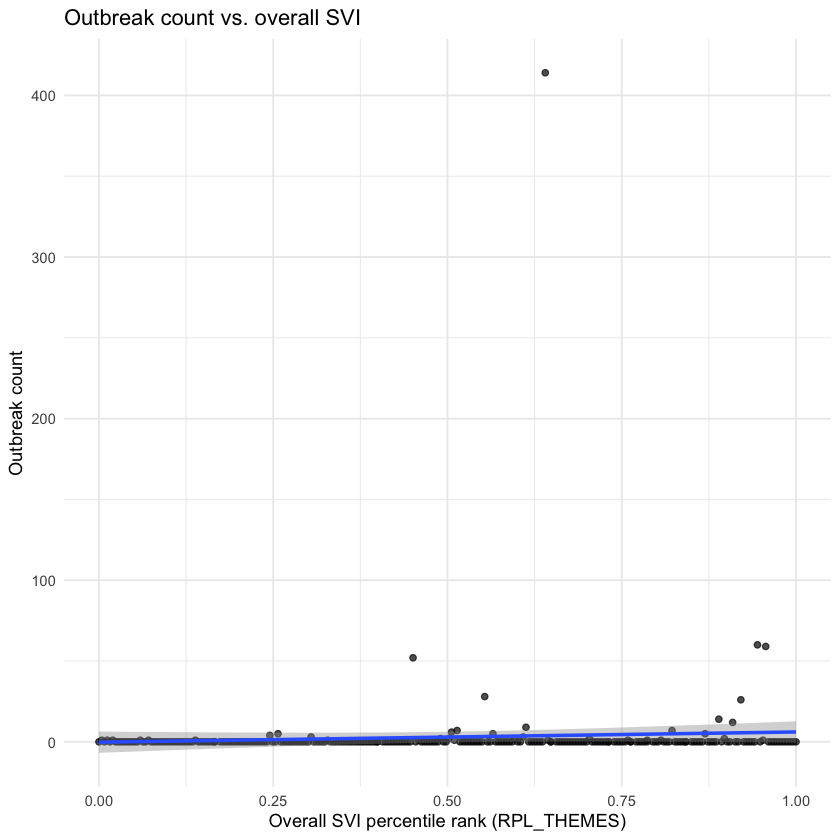

`geom_smooth()` using formula = 'y ~ x'


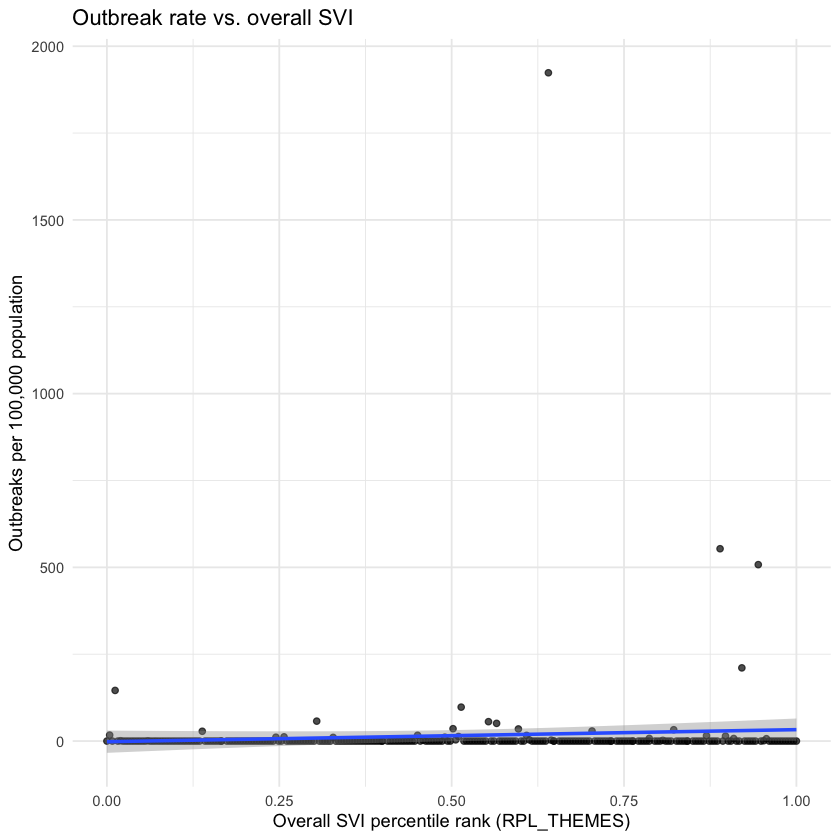

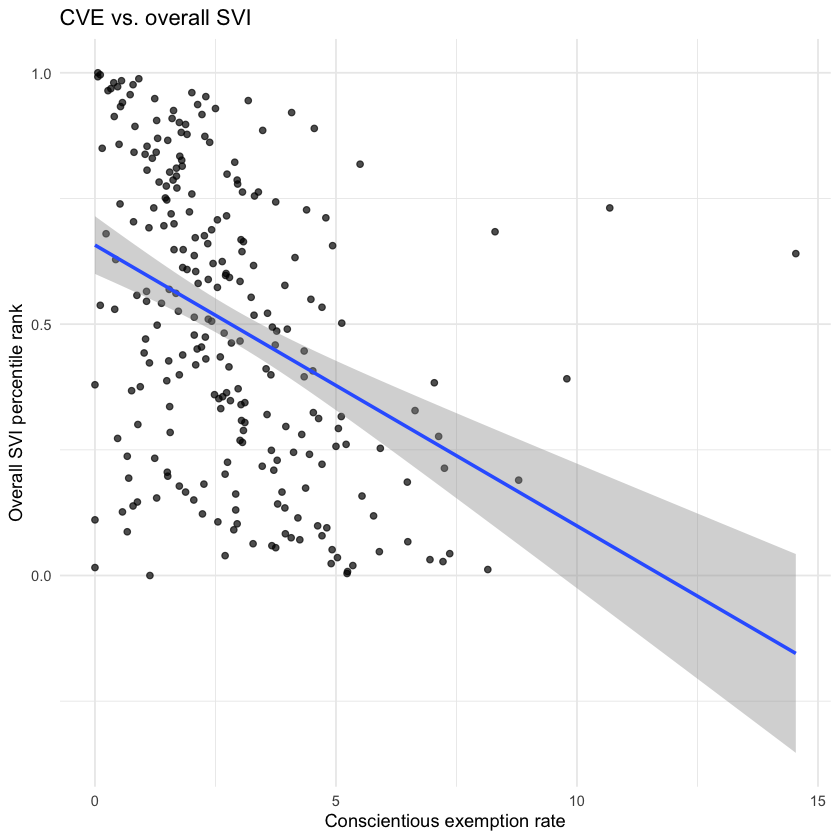

In [16]:
library(ggplot2)

ggplot(county_full, aes(x = RPL_THEMES, y = outbreak)) +
  geom_point(alpha = 0.7) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(
    title = "Outbreak count vs. overall SVI",
    x = "Overall SVI percentile rank (RPL_THEMES)",
    y = "Outbreak count"
  ) +
  theme_minimal()

ggplot(county_full, aes(x = RPL_THEMES, y = outbreak / population * 100000)) +
  geom_point(alpha = 0.7) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(
    title = "Outbreak rate vs. overall SVI",
    x = "Overall SVI percentile rank (RPL_THEMES)",
    y = "Outbreaks per 100,000 population"
  ) +
  theme_minimal()

ggplot(county_full, aes(x = cve, y = RPL_THEMES)) +
  geom_point(alpha = 0.7) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(
    title = "CVE vs. overall SVI",
    x = "Conscientious exemption rate",
    y = "Overall SVI percentile rank"
  ) +
  theme_minimal()

In [17]:
# negative binomial models
analysis_df <- county_full %>%
  filter(
    !is.na(outbreak),
    !is.na(population),
    population > 0,
    !is.na(RPL_THEMES)
  )

# Model 1: SVI only
model_svi_only <- glm.nb(
  outbreak ~ scale(RPL_THEMES) + offset(log(population)),
  data = analysis_df
)

summary(model_svi_only)

# Model 2: Theme-specific SVI
model_svi_themes <- glm.nb(
  outbreak ~ scale(RPL_THEME1) + scale(RPL_THEME2) +
    scale(RPL_THEME3) + scale(RPL_THEME4) +
    offset(log(population)),
  data = analysis_df
)

summary(model_svi_themes)

# Model 3: CVE + overall SVI
model_cve_svi <- glm.nb(
  outbreak ~ scale(cve) + scale(RPL_THEMES) +
    offset(log(population)),
  data = analysis_df
)

summary(model_cve_svi)

cor(analysis_df %>%
      dplyr::select(RPL_THEME1, RPL_THEME2, RPL_THEME3, RPL_THEME4))


Call:
glm.nb(formula = outbreak ~ scale(RPL_THEMES) + offset(log(population)), 
    data = analysis_df, init.theta = 0.03846304023, link = log)

Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
(Intercept)        -9.2467     0.3376 -27.391  < 2e-16 ***
scale(RPL_THEMES)   1.1404     0.3459   3.297 0.000978 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for Negative Binomial(0.0385) family taken to be 1)

    Null deviance: 89.380  on 253  degrees of freedom
Residual deviance: 82.372  on 252  degrees of freedom
AIC: 440.08

Number of Fisher Scoring iterations: 1


              Theta:  0.03846 
          Std. Err.:  0.00731 

 2 x log-likelihood:  -434.08200 


Call:
glm.nb(formula = outbreak ~ scale(RPL_THEME1) + scale(RPL_THEME2) + 
    scale(RPL_THEME3) + scale(RPL_THEME4) + offset(log(population)), 
    data = analysis_df, init.theta = 0.0415922748, link = log)

Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
(Intercept)        -9.4476     0.3228 -29.268  < 2e-16 ***
scale(RPL_THEME1)   1.2370     0.4739   2.610 0.009044 ** 
scale(RPL_THEME2)   0.4521     0.3910   1.156 0.247608    
scale(RPL_THEME3)   0.4747     0.3934   1.207 0.227589    
scale(RPL_THEME4)  -1.3584     0.4054  -3.350 0.000807 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for Negative Binomial(0.0416) family taken to be 1)

    Null deviance: 95.276  on 253  degrees of freedom
Residual deviance: 83.485  on 249  degrees of freedom
AIC: 442.1

Number of Fisher Scoring iterations: 1


              Theta:  0.04159 
          Std. Err.:  0.00803 

 2 x log-likelihood:  -430.09700 


Call:
glm.nb(formula = outbreak ~ scale(cve) + scale(RPL_THEMES) + 
    offset(log(population)), data = analysis_df, init.theta = 0.05627045932, 
    link = log)

Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
(Intercept)       -10.2386     0.2981 -34.349  < 2e-16 ***
scale(cve)          1.0080     0.3311   3.045  0.00233 ** 
scale(RPL_THEMES)   1.0655     0.3395   3.138  0.00170 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for Negative Binomial(0.0563) family taken to be 1)

    Null deviance: 121.734  on 253  degrees of freedom
Residual deviance:  86.168  on 251  degrees of freedom
AIC: 421.45

Number of Fisher Scoring iterations: 1


              Theta:  0.0563 
          Std. Err.:  0.0114 

 2 x log-likelihood:  -413.4520 

,RPL_THEME1,RPL_THEME2,RPL_THEME3,RPL_THEME4
RPL_THEME1,1.0000000,0.5098441,0.5357795,0.5635794
RPL_THEME2,0.5098441,1.0000000,0.4184368,0.2542938
RPL_THEME3,0.5357795,0.4184368,1.0000000,0.3787073
RPL_THEME4,0.5635794,0.2542938,0.3787073,1.0000000


In [18]:

# Model 4: CVE + SVI themes
model_cve_svi_themes <- glm.nb(
  outbreak ~ scale(cve) +
    scale(RPL_THEME1) + scale(RPL_THEME2) +
    scale(RPL_THEME3) + scale(RPL_THEME4) +
    offset(log(population)),
  data = analysis_df
)

summary(model_cve_svi_themes)

# -----------------------------
# 13. Optional interaction model
# -----------------------------
# # Example: does CVE matter more in more vulnerable counties?
# model_interaction <- glm.nb(
#   outbreak ~ scale(cve) * scale(RPL_THEMES) +
#     offset(log(population)),
#   data = analysis_df
# )

# summary(model_interaction)

# -----------------------------
# 14. IRR tables
# -----------------------------
irr_table <- function(model) {
  broom::tidy(model, conf.int = TRUE, exponentiate = TRUE) %>%
    mutate(across(where(is.numeric), ~round(.x, 3)))
}

irr_table(model_svi_only)
irr_table(model_svi_themes)
irr_table(model_cve_svi)
irr_table(model_cve_svi_themes)
irr_table(model_interaction)

# -----------------------------
# 15. Compare models
# -----------------------------
AIC(model_svi_only, model_svi_themes, model_cve_svi,
    model_cve_svi_themes, model_interaction)

# -----------------------------
# 16. Optional: use enrollment offset instead
# -----------------------------
# If you want to mirror your older setup more closely, switch population to enrollment:
analysis_df_enr <- county_full %>%
  filter(
    !is.na(outbreak),
    !is.na(enrollment),
    enrollment > 0,
    !is.na(RPL_THEMES)
  )

model_cve_svi_enrollment <- glm.nb(
  outbreak ~ scale(cve) + scale(RPL_THEMES) +
    offset(log(enrollment)),
  data = analysis_df_enr
)

summary(model_cve_svi_enrollment)
irr_table(model_cve_svi_enrollment)



Call:
glm.nb(formula = outbreak ~ scale(cve) + scale(RPL_THEME1) + 
    scale(RPL_THEME2) + scale(RPL_THEME3) + scale(RPL_THEME4) + 
    offset(log(population)), data = analysis_df, init.theta = 0.0711354769, 
    link = log)

Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
(Intercept)       -10.6713     0.2790 -38.255  < 2e-16 ***
scale(cve)          1.3698     0.3199   4.282 1.85e-05 ***
scale(RPL_THEME1)   1.1178     0.4156   2.689  0.00716 ** 
scale(RPL_THEME2)   0.1697     0.3359   0.505  0.61335    
scale(RPL_THEME3)   0.9561     0.3684   2.596  0.00944 ** 
scale(RPL_THEME4)  -1.1033     0.3513  -3.140  0.00169 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for Negative Binomial(0.0711) family taken to be 1)

    Null deviance: 146.912  on 253  degrees of freedom
Residual deviance:  87.733  on 248  degrees of freedom
AIC: 414.48

Number of Fisher Scoring iterations: 1


              Theta:  0.0711 
        

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),0.000,0.338,-27.391,0.000,0.000,0.000
scale(RPL_THEMES),3.128,0.346,3.297,0.001,1.347,7.523


term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),0.000,0.323,-29.268,0.000,0.000,0.000
scale(RPL_THEME1),3.445,0.474,2.610,0.009,0.634,16.949
scale(RPL_THEME2),1.572,0.391,1.156,0.248,0.464,4.456
scale(RPL_THEME3),1.607,0.393,1.207,0.228,0.433,5.309
scale(RPL_THEME4),0.257,0.405,-3.350,0.001,0.061,1.132


term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),0.000,0.298,-34.349,0.000,0.000,0.000
scale(cve),2.740,0.331,3.045,0.002,1.571,6.040
scale(RPL_THEMES),2.902,0.340,3.138,0.002,1.543,5.909


Warning message:
"glm.fit: Algorithmus konvergierte nicht"


term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),0.000,0.279,-38.255,0.000,0.000,0.000
scale(cve),3.934,0.320,4.282,0.000,1.922,10.341
scale(RPL_THEME1),3.058,0.416,2.689,0.007,1.129,8.278
scale(RPL_THEME2),1.185,0.336,0.505,0.613,0.618,2.149
scale(RPL_THEME3),2.602,0.368,2.596,0.009,1.195,5.642
scale(RPL_THEME4),0.332,0.351,-3.140,0.002,0.136,0.797


ERROR: Error in eval(expr, envir, enclos): Objekt 'model_interaction' nicht gefunden


In [19]:
library(dplyr)
library(MASS)

analysis_df2 <- analysis_df %>%
  mutate(
    z_cve = as.numeric(scale(cve)),
    z_svi = as.numeric(scale(RPL_THEMES)),
    z_int = z_cve * z_svi
  ) %>%
  filter(
    !is.na(outbreak),
    !is.na(population),
    population > 0,
    is.finite(z_cve),
    is.finite(z_svi),
    is.finite(z_int)
  )

form_int <- outbreak ~ z_cve + z_svi + z_int + offset(log(population))

pois_int <- glm(
  form_int,
  data = analysis_df2,
  family = poisson(link = "log")
)

model_interaction <- glm.nb(
  form_int,
  data = analysis_df2,
  start = coef(pois_int),
  control = glm.control(maxit = 100)
)

summary(model_interaction)

ERROR: Error: keine zul"assigen Koeffizienten gefunden: bitte Startwerte angeben


In [20]:
analysis_df2 <- analysis_df %>%
  mutate(
    population = E_TOTPOP,
    z_cve = as.numeric(scale(cve)),
    z_svi = as.numeric(scale(RPL_THEMES))
  ) %>%
  mutate(
    z_int = z_cve * z_svi
  )

  summary(analysis_df2[, c("outbreak", "population", "z_cve", "z_svi", "z_int")])

sapply(analysis_df2[, c("outbreak", "population", "z_cve", "z_svi", "z_int")], function(x) {
  c(
    n_na = sum(is.na(x)),
    n_inf = sum(is.infinite(x)),
    sd = sd(x, na.rm = TRUE),
    min = min(x, na.rm = TRUE),
    max = max(x, na.rm = TRUE)
  )
})

    outbreak         population          z_cve             z_svi          
 Min.   :  0.000   Min.   :     96   Min.   :-1.4092   Min.   :-1.721748  
 1st Qu.:  0.000   1st Qu.:   6306   1st Qu.:-0.6626   1st Qu.:-0.860685  
 Median :  0.000   Median :  18383   Median :-0.1637   Median : 0.000377  
 Mean   :  2.925   Mean   : 115131   Mean   : 0.0000   Mean   : 0.000000  
 3rd Qu.:  0.000   3rd Qu.:  52424   3rd Qu.: 0.4741   3rd Qu.: 0.861439  
 Max.   :414.000   Max.   :4726177   Max.   : 5.8637   Max.   : 1.722502  
     z_int         
 Min.   :-4.48330  
 1st Qu.:-0.80087  
 Median :-0.15923  
 Mean   :-0.38316  
 3rd Qu.: 0.05976  
 Max.   : 3.13331  

,outbreak,population,z_cve,z_svi,z_int
n_na,0.00000,0.0,0.000000,0.000000,0.0000000
n_inf,0.00000,0.0,0.000000,0.000000,0.0000000
sd,26.75947,410669.3,1.000000,1.000000,0.9805489
min,0.00000,96.0,-1.409175,-1.721748,-4.4833034
max,414.00000,4726177.0,5.863678,1.722502,3.1333086
